# Black Scholes / Volatility Swaps Price Production Audit 01

Validate the first 100 production rows with the four independent engines.

## Load Data And Timings

Load the production audit and display the common four-engine timing view.

,wall seconds,kernel seconds
engine,,
cpp cuda,0.06639,0.05627
pytorch gpu,0.1102,-
cpp cpu,2.693,-
pytorch cpu,5.07,-


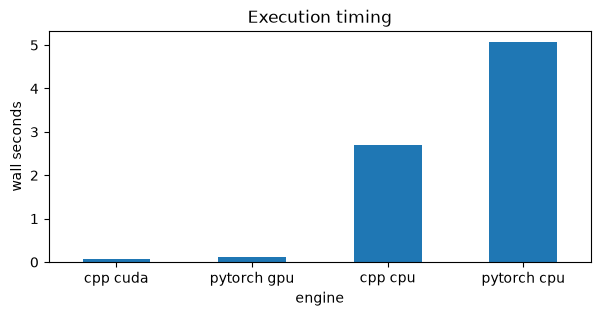

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "registry").is_dir())
PROJECT_ROOT = ROOT
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src_python") not in sys.path:
    sys.path.insert(0, str(ROOT / "src_python"))

from tools.validation.audit import load_production_audit, timing_frame

pd.set_option("display.precision", 4)
audit = load_production_audit(
    ROOT,
    model_family='black_scholes',
    product_family='volatility_swaps',
    delta_crn=False,
)
cpp_gpu = audit.validation["cpp_gpu"].data
python_gpu = audit.validation["python_gpu"].data
cpp_cpu = audit.validation["cpp_cpu"].data
python_cpu = audit.validation["python_cpu"].data
cpp_gpu_spec = audit.validation["cpp_gpu"].specification
cpp_gpu_spec_summary = cpp_gpu_spec["summary"]
production = audit.production.data
production_head = production["results"][:100]
data = {key: document.data for key, document in audit.validation.items()}
specs = {key: document.specification for key, document in audit.validation.items()}
paths = {key: document.json_path for key, document in audit.validation.items()}
spec_paths = {key: document.yaml_path for key, document in audit.validation.items()}
spec_path = spec_paths["cpp_gpu"]
result_path = paths["cpp_gpu"]
PRODUCT_FAMILY = 'volatility_swaps'
performance = timing_frame(audit)
benchmark_row_count = performance.attrs.get("benchmark_row_count")
if benchmark_row_count and benchmark_row_count != 100:
    print(
        f"Performance timing uses one hot call over {benchmark_row_count:,} "
        "benchmark rows; correctness retains the 100-row audit slice."
    )
display(performance.style.format("{:.4g}", na_rep="-"))
ax = performance["wall seconds"].plot(kind="bar", figsize=(7, 3), rot=0)
ax.set_ylabel("wall seconds")
ax.set_title("Execution timing")
plt.show()

## Dataset Coherence

Apply the production, native reproducibility, and statistical checks.

In [2]:
from tools.validation.audit import coherence_frame

coherence = coherence_frame(audit)
display(
    coherence.style.format(
        {
            "max abs error": "{:.3e}",
            "max rel error (%)": "{:.3f}",
            "max z-score": "{:.3f}",
        },
        na_rep="-",
    )
)

,output,max abs error,max rel error (%),relative rows,max z-score
check,,,,,
production stored cpp cuda vs regenerated cpp cuda,price,0.000e+00,0.000,100,0.000
cpp cpu vs cpp cuda,price,2.720e-15,0.000,100,0.000
pytorch cpu vs pytorch gpu,price,1.465e-03,4.346,100,3.584
cpp cuda vs pytorch gpu,price,1.050e-03,3.664,100,2.852


## Path Reconstruction Check

Reconstruct the exact Philox paths for one production row and reprice it.

In [3]:
from tools.paths.black_scholes import load_result_context, reconstruct_paths_from_context
import torch

row_id = "000001"
num_paths = int(cpp_gpu["row_count"] and cpp_gpu_spec_summary["num_paths"])
target_dt = cpp_gpu_spec["time_grid"]["target_dt"]

result_row, model, product, _ = load_result_context(
    result_json_path=paths["cpp_gpu"],
    result_yaml_path=spec_paths["cpp_gpu"],
    row_id=row_id,
)
num_steps = max(1, int(round(float(product["maturity"]) / (1 / 52))))
paths_matrix, kernel_seconds = reconstruct_paths_from_context(
    result_row=result_row,
    model=model,
    product=product,
    num_paths=num_paths,
    num_steps=num_steps,
    use_gpu=True,
)
paths_tensor = torch.tensor(paths_matrix, dtype=torch.float64)
rate = float(model["risk_free_rate"])
strike = float(product.get("strike", product.get("volatility_strike", 0.0)))
maturity = float(product["maturity"])
discount = math.exp(-rate * maturity)
if PRODUCT_FAMILY == "lookback_fixed_calls":
    values = discount * torch.clamp(paths_tensor.max(dim=1).values - strike, min=0.0)
elif PRODUCT_FAMILY == "asian_arithmetic_calls":
    values = discount * torch.clamp(paths_tensor[:, 1:].mean(dim=1) - strike, min=0.0)
elif PRODUCT_FAMILY == "volatility_swaps":
    log_returns = torch.diff(torch.log(paths_tensor), dim=1)
    realized_vol = torch.sqrt((log_returns * log_returns).sum(dim=1) / maturity)
    values = discount * (realized_vol - strike)
else:
    from ai_factory.pytorch.black_scholes.american_puts import price_from_paths_batch
    repriced = price_from_paths_batch(
        paths_tensor.unsqueeze(0),
        strikes=torch.tensor([strike], dtype=torch.float64),
        maturities=torch.tensor([[maturity]], dtype=torch.float64),
        rates=torch.tensor([[rate]], dtype=torch.float64),
    )[0]
    values = None
stored = next(row for row in cpp_gpu["results"] if row["id"] == row_id)["outputs"]
if values is not None:
    repriced = {
        "price": float(values.mean()),
        "standard_error": float(values.std(unbiased=True) / math.sqrt(num_paths)),
    }
summary = pd.DataFrame([
    {"quantity": "stored price", "value": stored["price"]},
    {"quantity": "repriced from reconstructed paths", "value": repriced["price"]},
    {"quantity": "absolute error", "value": abs(stored["price"] - repriced["price"])},
    {"quantity": "path kernel seconds", "value": kernel_seconds if kernel_seconds is not None else "-"},
])
display(summary)


,quantity,value
0,stored price,-2.9857e-02
1,repriced from reconstructed paths,-2.9857e-02
2,absolute error,3.4694e-18
3,path kernel seconds,1.1848e-03


## Regeneration Commands

The commands below rebuild the native library and regenerate this audit chain.

```bash
cmake -S src_cpp -B /tmp/ai_factory_cpp_build -DCMAKE_BUILD_TYPE=Release
cmake --build /tmp/ai_factory_cpp_build --target ai_factory_cuda_shared -j
python registry/production/models/black_scholes/generators/black_scholes_01.py
python registry/production/results/black_scholes/volatility_swaps/generators/black_scholes_01__volatility_swaps_01__cpp_gpu_philox_01.py
python registry/validation/models/black_scholes/generators/black_scholes_01__first_100.py
python registry/validation/results/black_scholes/volatility_swaps/generators/black_scholes_01__first_100__volatility_swaps_01__first_100__cpp_gpu_philox_01.py
python registry/validation/results/black_scholes/volatility_swaps/generators/black_scholes_01__first_100__volatility_swaps_01__first_100__cpp_cpu_philox_01.py
python registry/validation/results/black_scholes/volatility_swaps/generators/black_scholes_01__first_100__volatility_swaps_01__first_100__python_gpu_pytorch_01.py
python registry/validation/results/black_scholes/volatility_swaps/generators/black_scholes_01__first_100__volatility_swaps_01__first_100__python_cpu_pytorch_01.py
```